# MLP Visualization

This notebook loads initial embeddings and embeddings compressed using MLP, then visualize it using t-SNE

## Load embedding vectors

Loading initial and compressed embeddings from chromadb

In [1]:
import os
import chromadb
import numpy as np
import json

In [2]:
INITIAL_NPY_PATH = '../data/hive/embeddings/initial_embeddings.npy'
LABEL_PATH = '../data/hive/labels.json'
PROCESSED_NPY_PATH = '../data/hive/embeddings/01_compressed_embeddings.npy'


In [3]:
initial_embeddings = np.load(INITIAL_NPY_PATH)
with open(LABEL_PATH, 'r') as f:
    labels = json.load(f)

processed_embeddings = np.load(PROCESSED_NPY_PATH)

## Visualization using t-SNE

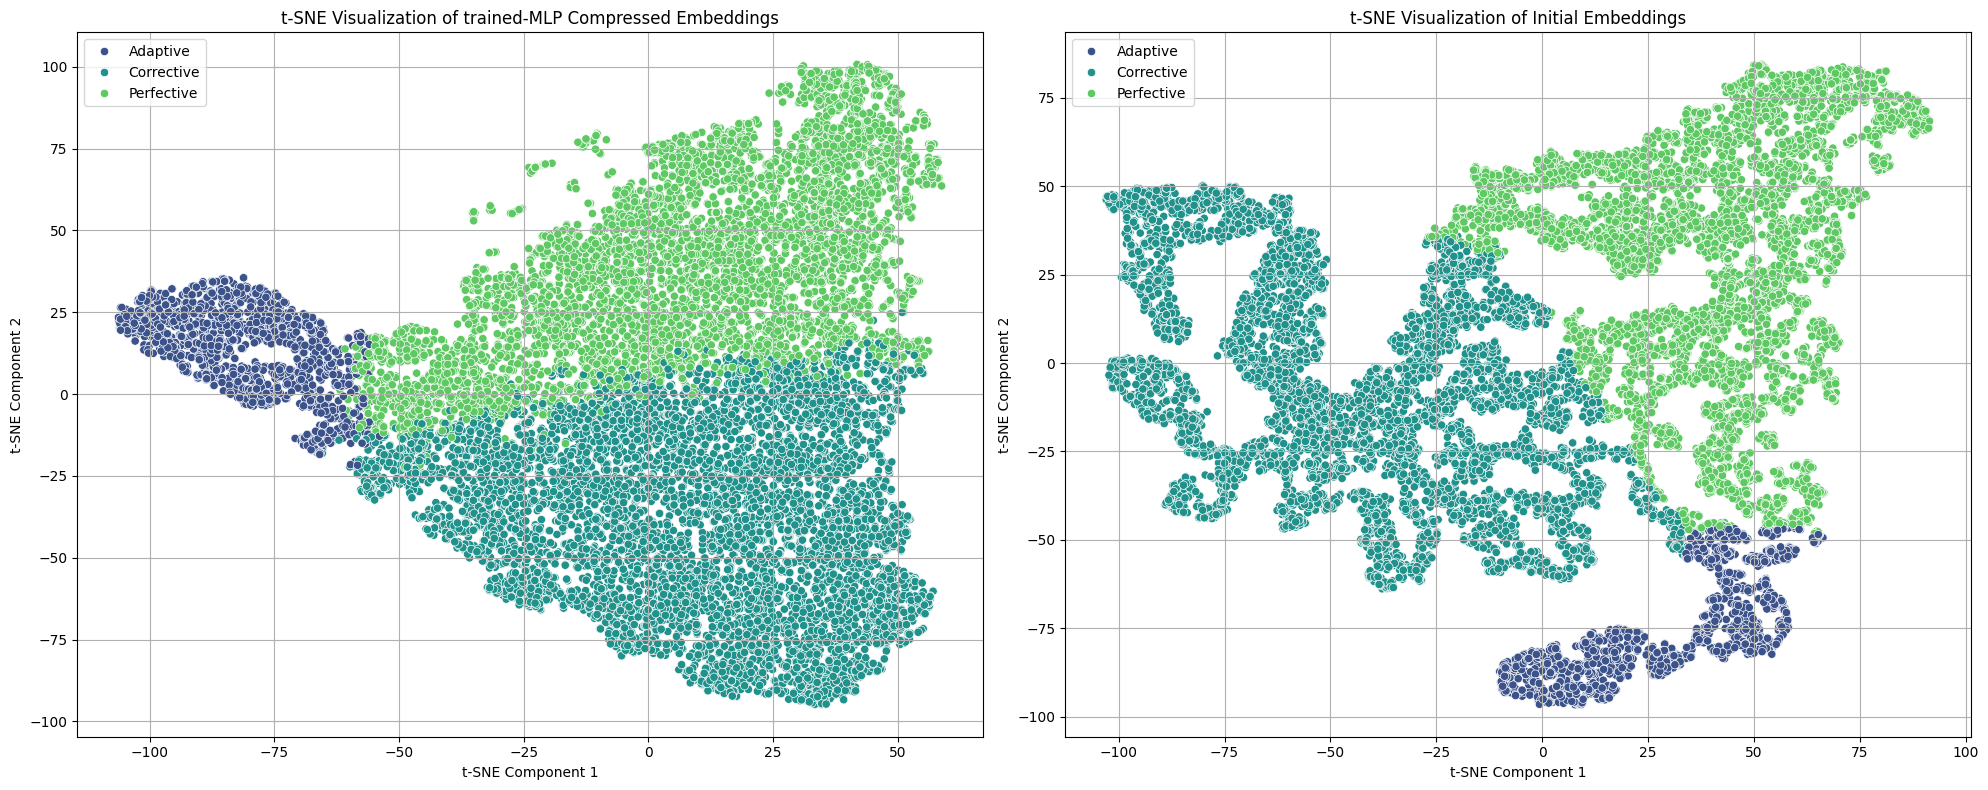

In [4]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Reduce the dimensions of the compressed embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(processed_embeddings)

# Plot compressed embeddings
sns.scatterplot(x=embeddings_2d[:, 0], 
                y=embeddings_2d[:, 1], 
                palette='viridis',
                hue=labels,
                ax=ax1)
ax1.set_title('t-SNE Visualization of trained-MLP Compressed Embeddings')
ax1.set_xlabel('t-SNE Component 1')
ax1.set_ylabel('t-SNE Component 2')
ax1.grid(True)

# Plot initial embeddings
initial_tsne = TSNE(n_components=2, random_state=42)
initial_embeddings_2d = initial_tsne.fit_transform(initial_embeddings)

sns.scatterplot(x=initial_embeddings_2d[:, 0], 
                y=initial_embeddings_2d[:, 1], 
                palette='viridis',
                hue=labels,
                ax=ax2)
ax2.set_title('t-SNE Visualization of Initial Embeddings')
ax2.set_xlabel('t-SNE Component 1')
ax2.set_ylabel('t-SNE Component 2')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Visualization using UMAP


In [5]:
import umap
reducer = umap.UMAP()
reduced_compressed_embeddings = reducer.fit_transform(compressed_embeddings_np)
reduced_initial_embeddings = reducer.fit_transform(embeddings_tensor)

NameError: name 'compressed_embeddings_np' is not defined